In [1]:
'''
KerasGA https://pypi.org/project/KerasGA/   https://pygad.readthedocs.io/en/latest/kerasga.html
Fuente: https://anderfernandez.com/blog/algoritmo-genetico-en-python/#C%C3%B3mo-usar-un-algoritmo-gen%C3%A9tico-en-Python-con-PyGAD
AG en 5 minutos: https://www.youtube.com/watch?v=RBrXGyo0kIw&list=RDLV_ZxrvAi0Mk0&index=7
Colab: http://fcaglp.unlp.edu.ar/~gbaume/grupo/Publicaciones/Apuntes/GoogleColab.pdf
'''
!pip install pygad
import warnings
import seaborn as sns
import numpy as np
import pandas as pd

#from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from keras.models import Sequential
from keras.layers import Dense, Input
from keras.losses import BinaryCrossentropy

from pygad import kerasga, GA

warnings.simplefilter('ignore')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 1.8 MB/s eta 0:00:00


In [2]:
url="https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"

#r = requests.get(url).content
#data = pd.read_csv(io.StringIO(r.decode('utf-8')))
data=pd.read_csv(url)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
data['Outcome'].unique()

array([1, 0])

<Axes: xlabel='Outcome'>

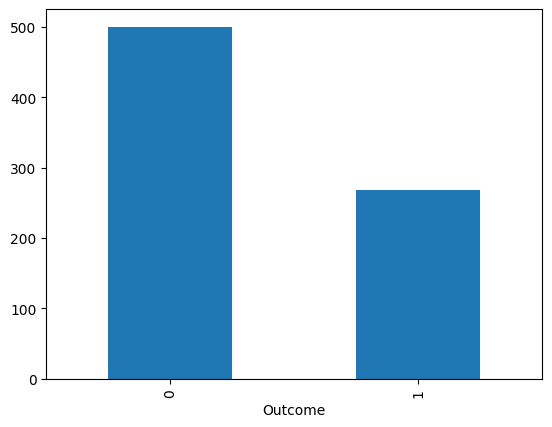

In [3]:
bar=data['Outcome'].value_counts()
bar.plot(kind='bar')


In [4]:
target=data.pop('Outcome')
target

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [5]:
data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [6]:
# SEPARAR TRAIN Y TEST
x_train, x_test, y_train, y_test = train_test_split(data, target, stratify=target, random_state=16)
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
402,5,136,84,41,88,35.0,0.286,35
315,2,112,68,22,94,34.1,0.315,26
199,4,148,60,27,318,30.9,0.150,29
720,4,83,86,19,0,29.3,0.317,34
589,0,73,0,0,0,21.1,0.342,25
...,...,...,...,...,...,...,...,...
473,7,136,90,0,0,29.9,0.210,50
494,3,80,0,0,0,0.0,0.174,22
231,6,134,80,37,370,46.2,0.238,46
475,0,137,84,27,0,27.3,0.231,59


In [ ]:
y_train

391    1
270    1
42     0
654    0
24     1
      ..
395    0
542    1
223    0
555    0
643    0
Name: Outcome, Length: 576, dtype: int64

In [7]:
scaler=StandardScaler()
x_train_sc=scaler.fit_transform(x_train)
x_train_sc

array([[ 0.34635499,  1.37973851,  0.34353814, ...,  1.73635062,
        -0.40064743, -0.51465232],
       [ 1.80682696, -0.61337091,  0.85248354, ...,  1.72348363,
         1.89410892,  0.43602905],
       [ 0.93054377, -0.4600548 ,  1.15785078, ..., -1.22305617,
        -0.70334771,  1.30028484],
       ...,
       [ 0.93054377,  0.64382119, -0.47077449, ..., -0.43817002,
         0.5997049 ,  2.42381737],
       [ 0.93054377,  0.0918832 ,  0.0381709 , ..., -0.86278056,
        -0.91667933,  0.34960347],
       [ 0.05426059, -0.95066635, -3.52444687, ..., -0.54110591,
         0.3777247 , -0.16895   ]])

In [10]:
x_train_sc.shape

(576, 8)

In [8]:
x_test_sc=scaler.transform(x_test)
x_test_sc

array([[ 0.34635499,  0.45984186,  0.75069446, ...,  0.35958311,
        -0.55632186,  0.17675231],
       [-0.5299282 , -0.27607547, -0.06361817, ...,  0.24378024,
        -0.47271893, -0.6010779 ],
       [ 0.05426059,  0.82780052, -0.47077449, ..., -0.16796331,
        -0.94839079, -0.34180116],
       ...,
       [ 0.63844938,  0.39851541,  0.5471163 , ...,  1.80068555,
        -0.69469913,  1.12743369],
       [-1.11411699,  0.49050508,  0.75069446, ..., -0.63117481,
        -0.71487915,  2.25096622],
       [-0.82202259,  1.31841207,  0.64890538, ...,  0.07650942,
        -0.39776457,  1.473136  ]])

In [23]:
# CREAMOS UNA RED FULLY CONECTED CON 2 CAPAs OCULTAs Y 16 / 8 NEURONAS CON ACTIVACIÓN RELU PARA CLASIFICAR

model = Sequential()
model.add(Input(shape=(x_train_sc.shape[1],)))
model.add(Dense(16, activation='relu'))
#model.add(Dense(8, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
#  acá aparece la magia: integración entre red y AG!!! by Keras :)
# https://pygad.readthedocs.io/en/latest/kerasga.html#examples

keras_ga = kerasga.KerasGA(model = model, num_solutions = 15)

In [25]:
#   para optimizar los parámetros, creamos el AG: primero definir FITNESS

def fitness_func(ga_instance, solution, solution_idx ):
  global model

  # Get the weights from the model
  weights = kerasga.model_weights_as_matrix(model= model,
                                            weights_vector= solution)

  # Set the weights
  model.set_weights(weights = weights)

  # Make the prediction
  prediction = model.predict(x_train_sc, verbose=0)

  # Calculate fitness
  entropy = BinaryCrossentropy()(y_train, prediction)
  fitness = 1/(entropy.numpy() + 0.0001)

  return fitness


In [26]:
#    agregamos un 'callback' para observar cómo va aprendiendo la red neuronal

fitness_evol = []

def callback_generation(ga_instance):

  global fitness_evol
  fitness_evol.append(ga_instance.best_solution()[1])
  generation = ga_instance.generations_completed

  if generation % 5 == 0:
    print(f"Generation {generation}. Fitness: {ga_instance.best_solution()[1]}")


In [27]:
#  ya podemos entrenar la red usando las soluciones del AG

num_generations = 100
num_parents_mating = 5
initial_population = keras_ga.population_weights

ga_optimizer = GA(num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    initial_population=initial_population,
    fitness_func=fitness_func, on_generation=callback_generation)

ga_optimizer.run()

Generation 5. Fitness: 1.8773084511742368
Generation 10. Fitness: 1.917837168263819
Generation 15. Fitness: 1.9806357256183769
Generation 20. Fitness: 1.9806357256183769
Generation 25. Fitness: 1.9806357256183769
Generation 30. Fitness: 2.0145833636563633
Generation 35. Fitness: 2.0145833636563633
Generation 40. Fitness: 2.0145833636563633
Generation 45. Fitness: 2.0145833636563633
Generation 50. Fitness: 2.0145833636563633
Generation 55. Fitness: 2.0145833636563633
Generation 60. Fitness: 2.0145833636563633
Generation 65. Fitness: 2.0145833636563633
Generation 70. Fitness: 2.0145833636563633
Generation 75. Fitness: 2.0145833636563633
Generation 80. Fitness: 2.0145833636563633
Generation 85. Fitness: 2.0164269382331654
Generation 90. Fitness: 2.0283217331904293
Generation 95. Fitness: 2.0283217331904293
Generation 100. Fitness: 2.0283217331904293


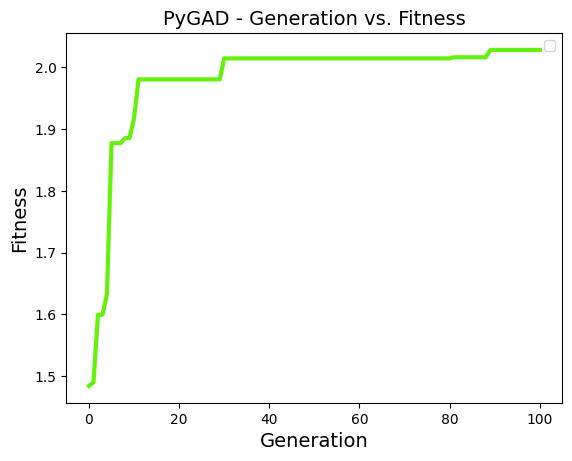

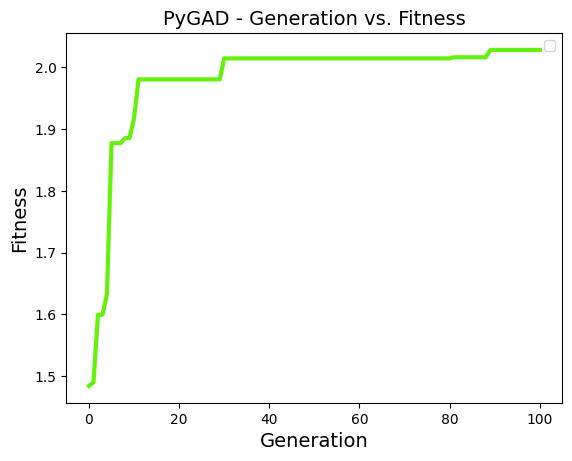

In [28]:
ga_optimizer.plot_fitness()

In [29]:
solution, solution_fitness, solution_idx = ga_optimizer.best_solution()


<Axes: >

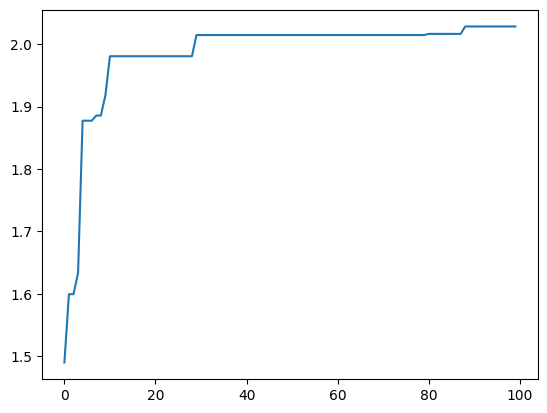

In [30]:
#   para ver cómo fue aprendiendo el modelo, graficamos su evolución
import seaborn as sns
sns.lineplot(x = range(len(fitness_evol)),
             y = fitness_evol)


In [31]:
#   ahora pedimos a la RN q prediga sobre datos nuevos (usamos el cjto de test) y vemos cómo le va
# hay dos maneras de obtener las predicciones


pred = kerasga.predict(model=model, solution=solution, data=x_test_sc)
pred


array([[0.50165063],
       [0.21518368],
       [0.6452916 ],
       [0.10703047],
       [0.03253108],
       [0.01598679],
       [0.50746495],
       [0.45171013],
       [0.30959418],
       [0.05626383],
       [0.22875206],
       [0.21440914],
       [0.0568942 ],
       [0.4175645 ],
       [0.39057568],
       [0.83038414],
       [0.09918904],
       [0.4007189 ],
       [0.5201213 ],
       [0.3825669 ],
       [0.34837812],
       [0.74977756],
       [0.38763142],
       [0.48458517],
       [0.19570896],
       [0.21864134],
       [0.45906767],
       [0.51880085],
       [0.22605774],
       [0.3288327 ],
       [0.18220994],
       [0.04024808],
       [0.1506606 ],
       [0.2750834 ],
       [0.1631883 ],
       [0.47587648],
       [0.05290964],
       [0.17416652],
       [0.02769944],
       [0.06175859],
       [0.04212545],
       [0.28652352],
       [0.14549503],
       [0.3223841 ],
       [0.2222128 ],
       [0.70429426],
       [0.30036741],
       [0.076

In [32]:
print(type(y_test))
print(type(pred))


<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>


In [33]:
import numpy as np
pred=np.round(pred,0)
pred

array([[1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],

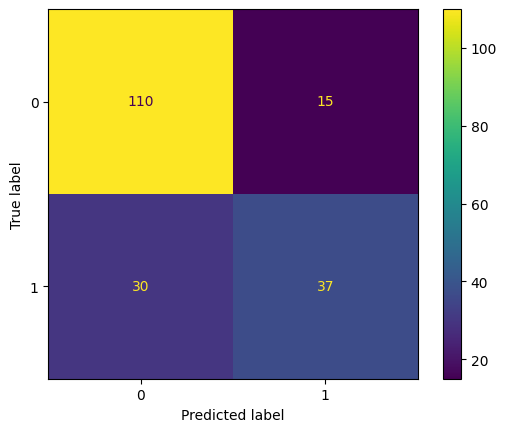

In [34]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
